# Distillation Loss Check

Reads `val_metrics.json` from every adapter under `models/distillation-sweep/` and inspects the final `val_eval_loss` to sanity-check that all distillation runs trained properly.

Each adapter directory is named `{teacher}--{student}--{condition}--lr{lr}--v7_adapter`. The notebook parses that, joins on `val_metrics.json`, filters to the (teacher, student, condition) set reported in `distillation_results.ipynb`, and flags runs whose loss looks abnormal vs sibling LRs in the same (teacher × student × condition) combo.

In [22]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists() and not (PROJECT_ROOT / "CLAUDE.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SWEEP_DIR = PROJECT_ROOT / "models" / "distillation-sweep"
assert SWEEP_DIR.exists(), f"Missing sweep dir: {SWEEP_DIR}"
print(f"Project root: {PROJECT_ROOT}")
print(f"Sweep dir:    {SWEEP_DIR}")

Project root: /scratch/s4626451/intention-jailbreak
Sweep dir:    /scratch/s4626451/intention-jailbreak/models/distillation-sweep


In [23]:
# Mirror the canonical sets from notebooks/distillation/distillation_results.ipynb
# so the loss check stays scoped to the models actually reported in the paper.
TEACHERS = {
    "cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit": "Mistral Small 4 119B",
    "Qwen-Qwen3-32B":                              "Qwen3 32B",
    "openai-gpt-oss-120b":                         "GPT-OSS 120B",
    "RedHatAI-gemma-3-27b-it-quantized.w4a16":     "Gemma 3 27B",
}
STUDENTS = {
    "gemma-3-12b":              "Gemma 3 12B",
    "llama-3.1-8b":             "Llama 3.1 8B",
    "ministral-3-14b-instruct": "Ministral 3 14B",
    "qwen3-8b":                 "Qwen3 8B",
}
CONDITIONS = {
    "no_intent":        "No Intent",
    "synthetic_intent": "Synthetic Intent",
    "human_intent":     "Human Intent",
}

TEACHER_SLUG_ORDER   = list(TEACHERS.keys())
STUDENT_SLUG_ORDER   = list(STUDENTS.keys())
CONDITION_SLUG_ORDER = list(CONDITIONS.keys())
TEACHER_ORDER   = list(TEACHERS.values())
STUDENT_ORDER   = list(STUDENTS.values())
CONDITION_ORDER = list(CONDITIONS.values())

In [24]:
ADAPTER_RE = re.compile(
    r"^(?P<teacher>.+?)--(?P<student>.+?)--(?P<condition>.+?)--lr(?P<lr>[0-9.e+-]+)--v7_adapter$"
)

rows = []
missing_metrics = []
skipped_unknown = []
for adapter_dir in sorted(SWEEP_DIR.iterdir()):
    if not adapter_dir.is_dir():
        continue
    m = ADAPTER_RE.match(adapter_dir.name)
    if not m:
        print(f"[skip] unparseable: {adapter_dir.name}")
        continue
    teacher_slug = m.group("teacher")
    student_slug = m.group("student")
    condition_slug = m.group("condition").replace("-", "_")
    if teacher_slug not in TEACHERS or student_slug not in STUDENTS or condition_slug not in CONDITIONS:
        skipped_unknown.append(adapter_dir.name)
        continue
    metrics_path = adapter_dir / "val_metrics.json"
    if not metrics_path.exists():
        missing_metrics.append(adapter_dir.name)
        continue
    with metrics_path.open() as f:
        metrics = json.load(f)
    rows.append({
        "teacher_slug":      teacher_slug,
        "teacher":           TEACHERS[teacher_slug],
        "student_slug":      student_slug,
        "student":           STUDENTS[student_slug],
        "condition_slug":    condition_slug,
        "condition":         CONDITIONS[condition_slug],
        "lr":                float(m.group("lr")),
        "val_eval_loss":     metrics.get("val_eval_loss"),
        "val_harm_f1":       metrics.get("val_harm_f1"),
        "val_harm_precision":metrics.get("val_harm_precision"),
        "val_harm_recall":   metrics.get("val_harm_recall"),
        "val_semantic_sim":  metrics.get("val_semantic_sim"),
        "adapter":           adapter_dir.name,
    })

df = pd.DataFrame(rows)
df["teacher"]   = pd.Categorical(df["teacher"],   categories=TEACHER_ORDER,   ordered=True)
df["student"]   = pd.Categorical(df["student"],   categories=STUDENT_ORDER,   ordered=True)
df["condition"] = pd.Categorical(df["condition"], categories=CONDITION_ORDER, ordered=True)
df = df.sort_values(["teacher", "student", "condition", "lr"]).reset_index(drop=True)

print(f"Loaded {len(df)} in-scope adapters")
print(f"  missing val_metrics.json: {len(missing_metrics)}")
for name in missing_metrics:
    print(f"    - {name}")
print(f"  out-of-scope adapters skipped: {len(skipped_unknown)}")
for name in skipped_unknown:
    print(f"    - {name}")
df.head()

Loaded 190 in-scope adapters
  missing val_metrics.json: 0
  out-of-scope adapters skipped: 0


,teacher_slug,teacher,student_slug,student,condition_slug,condition,lr,val_eval_loss,val_harm_f1,val_harm_precision,val_harm_recall,val_semantic_sim,adapter
0,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral Small 4 119B,gemma-3-12b,Gemma 3 12B,no_intent,No Intent,0.00001,0.711886,0.717949,0.677419,0.763636,0.872982,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit--g...
1,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral Small 4 119B,gemma-3-12b,Gemma 3 12B,no_intent,No Intent,0.00002,0.664169,0.725076,0.722892,0.727273,0.883246,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit--g...
2,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral Small 4 119B,gemma-3-12b,Gemma 3 12B,no_intent,No Intent,0.00005,0.630647,0.759036,0.754491,0.763636,0.897359,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit--g...
3,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral Small 4 119B,gemma-3-12b,Gemma 3 12B,no_intent,No Intent,0.00010,0.628953,0.718563,0.710059,0.727273,0.879397,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit--g...
4,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral Small 4 119B,gemma-3-12b,Gemma 3 12B,synthetic_intent,Synthetic Intent,0.00001,0.696773,0.750000,0.699482,0.808383,0.881288,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit--g...


## Coverage check

Confirm every (teacher × student × condition) combo has all 4 LRs.

In [25]:
coverage = (
    df.groupby(["teacher", "student", "condition"], observed=True)
      .agg(n_lrs=("lr", "nunique"), lrs=("lr", lambda s: sorted(s.unique().tolist())))
      .reset_index()
)
expected_combos = len(TEACHERS) * len(STUDENTS) * len(CONDITIONS)
incomplete = coverage[coverage["n_lrs"] < 4]
print(f"Combos seen: {len(coverage)} / expected {expected_combos}")
print(f"Combos with < 4 LRs: {len(incomplete)}")
incomplete

Combos seen: 48 / expected 48
Combos with < 4 LRs: 2


,teacher,student,condition,n_lrs,lrs
26,GPT-OSS 120B,Gemma 3 12B,Human Intent,3,"[1e-05, 2e-05, 0.0001]"
43,Gemma 3 27B,Ministral 3 14B,Synthetic Intent,3,"[1e-05, 5e-05, 0.0001]"


## Per-combo loss table

`val_eval_loss` for every (teacher, student, condition) across the 4 LRs. Lower is better; a row where one LR is far higher than its siblings is a candidate failed run.

In [26]:
loss_pivot = df.pivot_table(
    index=["teacher", "student", "condition"],
    columns="lr",
    values="val_eval_loss",
    observed=True,
).round(4)
loss_pivot

lr                                                     0.00001  0.00002  \
teacher              student         condition                            
Mistral Small 4 119B Gemma 3 12B     No Intent          0.7119   0.6642   
                                     Synthetic Intent   0.6968   0.6535   
                                     Human Intent       0.7804   0.7274   
                     Llama 3.1 8B    No Intent          0.7989   0.7343   
                                     Synthetic Intent   0.7855   0.7246   
                                     Human Intent       0.8716   0.7970   
                     Ministral 3 14B No Intent          0.6981   0.6428   
                                     Synthetic Intent   0.6955   0.6419   
                                     Human Intent       0.7599   0.7035   
                     Qwen3 8B        No Intent          0.8097   0.7310   
                                     Synthetic Intent   0.7970   0.7200   
                                     Human Intent       0.8974   0.8023   
Qwen3 32B            Gemma 3 12B     No Intent          0.7162   0.6669   
                                     Synthetic Intent   0.5951   0.5572   
                                     Human Intent       0.7451   0.6945   
                     Llama 3.1 8B    No Intent          0.7932   0.7260   
                                     Synthetic Intent   0.6770   0.6190   
                                     Human Intent       0.8288   0.7573   
                     Ministral 3 14B No Intent          0.7237   0.6631   
                                     Synthetic Intent   0.6182   0.5677   
                                     Human Intent       0.7497   0.6920   
                     Qwen3 8B        No Intent          0.7254   0.6627   
                                     Synthetic Intent   0.6104   0.5557   
                                     Human Intent       0.7994   0.7124   
GPT-OSS 120B         Gemma 3 12B     No Intent          0.8174   0.7515   
                                     Synthetic Intent   0.8423   0.7705   
                                     Human Intent       0.9518   0.8672   
                     Llama 3.1 8B    No Intent          0.9530   0.8352   
                                     Synthetic Intent   0.9786   0.8584   
                                     Human Intent       1.0869   0.9567   
                     Ministral 3 14B No Intent          0.8079   0.7364   
                                     Synthetic Intent   0.8215   0.7492   
                                     Human Intent       0.9094   0.8328   
                     Qwen3 8B        No Intent          1.0555   0.8811   
                                     Synthetic Intent   1.0909   0.9054   
                                     Human Intent       1.2205   1.0105   
Gemma 3 27B          Gemma 3 12B     No Intent          0.6988   0.6704   
                                     Synthetic Intent   0.6963   0.6692   
                                     Human Intent       0.7847   0.7470   
                     Llama 3.1 8B    No Intent          0.9716   0.8823   
                                     Synthetic Intent   0.9740   0.8839   
                                     Human Intent       1.0376   0.9448   
                     Ministral 3 14B No Intent          0.8812   0.8049   
                                     Synthetic Intent   0.8798      NaN   
                                     Human Intent       0.9439   0.8624   
                     Qwen3 8B        No Intent          1.0867   0.9554   
                                     Synthetic Intent   1.0727   0.9453   
                                     Human Intent       1.1481   1.0173   

lr                                                     0.00005  0.00010  
teacher              student         condition                           
Mistral Small 4 119B Gemma 3 12B     No Intent          0.6306   0.6290  
                           

In [27]:
f1_pivot = df.pivot_table(
    index=["teacher", "student", "condition"],
    columns="lr",
    values="val_harm_f1",
    observed=True,
).round(4)
f1_pivot

lr                                                     0.00001  0.00002  \
teacher              student         condition                            
Mistral Small 4 119B Gemma 3 12B     No Intent          0.7179   0.7251   
                                     Synthetic Intent   0.7500   0.7123   
                                     Human Intent       0.7385   0.7283   
                     Llama 3.1 8B    No Intent          0.6403   0.6624   
                                     Synthetic Intent   0.6645   0.6775   
                                     Human Intent       0.6071   0.6148   
                     Ministral 3 14B No Intent          0.6047   0.6800   
                                     Synthetic Intent   0.6457   0.7106   
                                     Human Intent       0.6324   0.6920   
                     Qwen3 8B        No Intent          0.6481   0.6102   
                                     Synthetic Intent   0.6535   0.6556   
                                     Human Intent       0.6148   0.6312   
Qwen3 32B            Gemma 3 12B     No Intent          0.7354   0.7507   
                                     Synthetic Intent   0.7451   0.7225   
                                     Human Intent       0.7123   0.7006   
                     Llama 3.1 8B    No Intent          0.6809   0.6367   
                                     Synthetic Intent   0.6623   0.6490   
                                     Human Intent       0.6306   0.6104   
                     Ministral 3 14B No Intent          0.7059   0.7080   
                                     Synthetic Intent   0.5588   0.6811   
                                     Human Intent       0.5763   0.5833   
                     Qwen3 8B        No Intent          0.6367   0.6536   
                                     Synthetic Intent   0.6242   0.6355   
                                     Human Intent       0.6891   0.6301   
GPT-OSS 120B         Gemma 3 12B     No Intent          0.7751   0.7709   
                                     Synthetic Intent   0.7759   0.7801   
                                     Human Intent       0.7412   0.7611   
                     Llama 3.1 8B    No Intent          0.6740   0.6951   
                                     Synthetic Intent   0.6974   0.6795   
                                     Human Intent       0.7166   0.6921   
                     Ministral 3 14B No Intent          0.6859   0.7297   
                                     Synthetic Intent   0.6767   0.6885   
                                     Human Intent       0.6386   0.7072   
                     Qwen3 8B        No Intent          0.7766   0.6993   
                                     Synthetic Intent   0.6865   0.6799   
                                     Human Intent       0.6335   0.6569   
Gemma 3 27B          Gemma 3 12B     No Intent          0.7225   0.7624   
                                     Synthetic Intent   0.7442   0.7258   
                                     Human Intent       0.7326   0.7371   
                     Llama 3.1 8B    No Intent          0.6950   0.7225   
                                     Synthetic Intent   0.6405   0.6667   
                                     Human Intent       0.6839   0.6708   
                     Ministral 3 14B No Intent          0.7151   0.6714   
                                     Synthetic Intent   0.7048      NaN   
                                     Human Intent       0.6716   0.6692   
                     Qwen3 8B        No Intent          0.6772   0.6991   
                                     Synthetic Intent   0.6797   0.6780   
                                     Human Intent       0.6953   0.6621   

lr                                                     0.00005  0.00010  
teacher              student         condition                           
Mistral Small 4 119B Gemma 3 12B     No Intent          0.7590   0.7186  
                           

## Outlier detection

For each (teacher, student, condition) flag any LR whose `val_eval_loss` is more than 1.5× the combo's minimum loss. These are the runs that most likely diverged or under-trained.

In [28]:
df = df.copy()
df["combo_min_loss"] = df.groupby(["teacher", "student", "condition"], observed=True)["val_eval_loss"].transform("min")
df["loss_ratio"] = df["val_eval_loss"] / df["combo_min_loss"]
outliers = df[df["loss_ratio"] > 1.5].sort_values("loss_ratio", ascending=False)
print(f"Outliers (loss_ratio > 1.5× combo min): {len(outliers)}")
outliers[["teacher", "student", "condition", "lr", "val_eval_loss", "combo_min_loss", "loss_ratio", "val_harm_f1"]]

Outliers (loss_ratio > 1.5× combo min): 0


,teacher,student,condition,lr,val_eval_loss,combo_min_loss,loss_ratio,val_harm_f1


## Loss-vs-LR plots per student

Quick visual scan: each subplot shows one student; lines are (teacher, condition); x-axis is LR; y-axis is `val_eval_loss`. A well-behaved sweep traces a U (or monotone) shape across LRs. A spike at a particular LR is a candidate failed run.

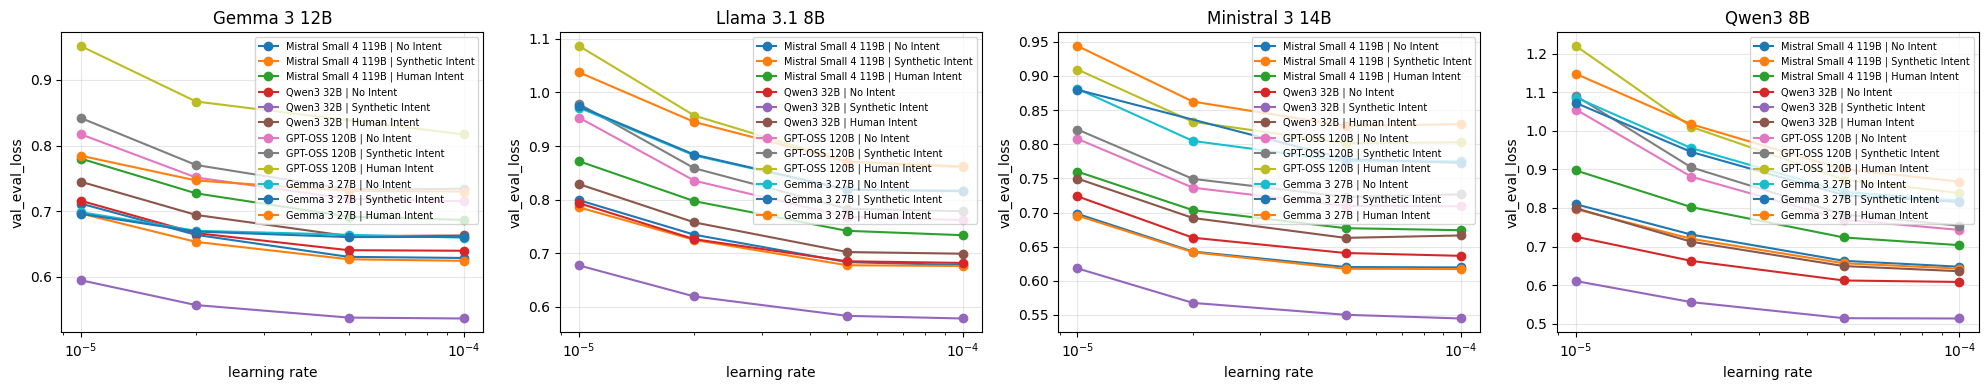

In [29]:
students = [s for s in STUDENT_ORDER if s in df["student"].unique()]
fig, axes = plt.subplots(1, len(students), figsize=(5 * len(students), 4), sharey=False)
if len(students) == 1:
    axes = [axes]

for ax, student in zip(axes, students):
    sub = df[df["student"] == student]
    for (teacher, condition), grp in sub.groupby(["teacher", "condition"], observed=True):
        grp = grp.sort_values("lr")
        label = f"{teacher} | {condition}"
        ax.plot(grp["lr"], grp["val_eval_loss"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("learning rate")
    ax.set_ylabel("val_eval_loss")
    ax.set_title(student)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="best")

plt.tight_layout()
plt.show()

## Best LR per combination

Selects the LR with the highest `val_harm_f1` per (teacher, student, condition) — this matches the W&B-based selection in `submit_distillation_eval.py` and is what gets submitted for OOD validation.

In [30]:
best = (
    df.sort_values("val_harm_f1", ascending=False)
      .groupby(["teacher", "student", "condition"], as_index=False, observed=True)
      .head(1)
      .sort_values(["teacher", "student", "condition"])
      .reset_index(drop=True)
)
best[["teacher", "student", "condition", "lr", "val_eval_loss", "val_harm_f1", "val_harm_precision", "val_harm_recall"]]

,teacher,student,condition,lr,val_eval_loss,val_harm_f1,val_harm_precision,val_harm_recall
0,Mistral Small 4 119B,Gemma 3 12B,No Intent,0.00005,0.630647,0.759036,0.754491,0.763636
1,Mistral Small 4 119B,Gemma 3 12B,Synthetic Intent,0.00001,0.696773,0.750000,0.699482,0.808383
2,Mistral Small 4 119B,Gemma 3 12B,Human Intent,0.00001,0.780350,0.738544,0.674877,0.815476
3,Mistral Small 4 119B,Llama 3.1 8B,No Intent,0.00010,0.677571,0.715976,0.699422,0.733333
4,Mistral Small 4 119B,Llama 3.1 8B,Synthetic Intent,0.00005,0.677369,0.679487,0.736111,0.630952
5,Mistral Small 4 119B,Llama 3.1 8B,Human Intent,0.00010,0.733498,0.652921,0.772358,0.565476
6,Mistral Small 4 119B,Ministral 3 14B,No Intent,0.00010,0.619620,0.710526,0.750000,0.675000
7,Mistral Small 4 119B,Ministral 3 14B,Synthetic Intent,0.00010,0.617212,0.730159,0.657143,0.821429
8,Mistral Small 4 119B,Ministral 3 14B,Human Intent,0.00010,0.674118,0.727273,0.685714,0.774194
9,Mistral Small 4 119B,Qwen3 8B,No Intent,0.00001,0.809705,0.648084,0.726562,0.584906


In [31]:
print("Summary stats over the best-LR adapters:")
best[["val_eval_loss", "val_harm_f1", "val_harm_precision", "val_harm_recall", "val_semantic_sim"]].describe().round(4)

Summary stats over the best-LR adapters:


,val_eval_loss,val_harm_f1,val_harm_precision,val_harm_recall,val_semantic_sim
count,48.0000,48.0000,48.0000,48.0000,48.0000
mean,0.7430,0.7150,0.7171,0.7244,0.8055
std,0.1046,0.0410,0.0489,0.0958,0.1449
min,0.5139,0.6087,0.6061,0.5509,0.4036
25%,0.6695,0.6805,0.6921,0.6369,0.7906
50%,0.7403,0.7236,0.7212,0.7298,0.8751
75%,0.8114,0.7444,0.7444,0.8087,0.8843
max,1.0555,0.7801,0.8214,0.8720,0.9043


## Loss heatmap per condition

Three-panel heatmap mirroring the OOD-F1 figure in `distillation_results.ipynb`: one panel per condition, teachers on rows, students on columns. Cell value is the `val_eval_loss` of the best-LR adapter (the one picked by `val_harm_f1`, i.e. the adapter that actually gets used downstream). Shared colour scale across panels; reversed colormap so darker = lower loss = better.

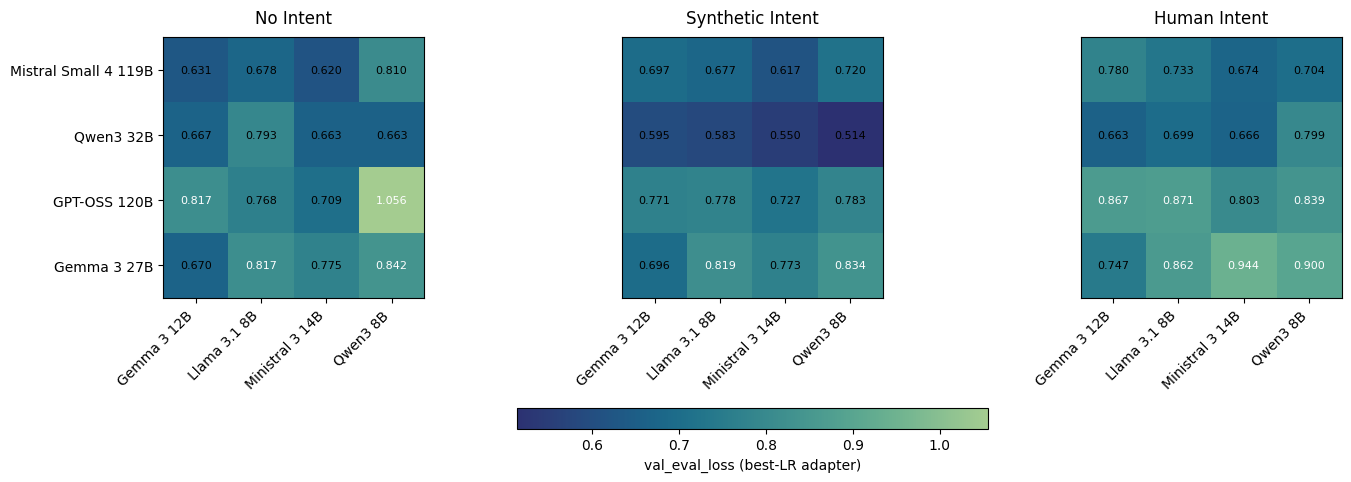

In [32]:
fig, axes = plt.subplots(1, len(CONDITION_SLUG_ORDER), figsize=(16, 4.5), sharey=True)
if len(CONDITION_SLUG_ORDER) == 1:
    axes = [axes]
for ax in axes[1:]:
    ax.yaxis.set_visible(False)

heatmap_min = float(best["val_eval_loss"].min(skipna=True))
heatmap_max = float(best["val_eval_loss"].max(skipna=True))
cmap = sns.color_palette("crest_r", as_cmap=True)

for ax, condition_slug in zip(axes, CONDITION_SLUG_ORDER):
    condition_name = CONDITIONS[condition_slug]
    pivot = (
        best[best["condition"] == condition_name]
        .pivot(index="teacher", columns="student", values="val_eval_loss")
        .reindex(index=TEACHER_ORDER, columns=STUDENT_ORDER)
    )
    image = ax.imshow(pivot.values, vmin=heatmap_min, vmax=heatmap_max, cmap=cmap)
    ax.set_title(condition_name, pad=10)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cell_value = pivot.iloc[i, j]
            if pd.isna(cell_value):
                ax.text(j, i, "—", ha="center", va="center", color="#888", fontsize=8)
                continue
            norm_val = (cell_value - heatmap_min) / (heatmap_max - heatmap_min + 1e-12)
            text_color = "white" if norm_val > 0.55 else "black"
            ax.text(j, i, f"{cell_value:.3f}", ha="center", va="center", color=text_color, fontsize=8)

fig.subplots_adjust(wspace=0, left=0.11, right=0.97, bottom=0.36, top=0.94)
_p0, _p2 = axes[0].get_position(), axes[-1].get_position()
_cbar_total_w = _p2.x1 - _p0.x0
_cbar_w = _cbar_total_w * 0.4
_cbar_left = _p0.x0 + (_cbar_total_w - _cbar_w) / 2
cbar_ax = fig.add_axes([_cbar_left, 0.07, _cbar_w, 0.045])
fig.colorbar(image, cax=cbar_ax, orientation="horizontal", label="val_eval_loss (best-LR adapter)")

FIGURES_DIR = PROJECT_ROOT / "notebooks" / "distillation" / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
fig.savefig(FIGURES_DIR / "distillation_loss_heatmap.pdf", bbox_inches="tight")
plt.show()

## Parse-failure analysis on OOD val outputs

The binary-metrics path in `distillation_results.ipynb` treats `predicted_harm=None` as `safe`. If a student fails to emit the expected `Prompt harm:` token on OOD prompts (e.g. it refuses with prose instead, or drifts out of format), every harmful prompt that hits this branch becomes a false negative — looking identical to "overfitting" but really a format-collapse issue.

Walks every JSONL under `data/safety_experiment/ood_validation/distillation/` and counts `predicted_harm is None` records. Aggregated by student → per-student parse-failure rate. Then split by (teacher × student) for each condition, mirroring the OOD-F1 heatmap layout.

In [33]:
OOD_VAL_ROOT = PROJECT_ROOT / "data" / "safety_experiment" / "ood_validation" / "distillation"
OOD_VAL_DATASETS = {"toxic-chat": "Toxic Chat", "aegis": "Aegis"}

parse_rows = []
for teacher_slug in TEACHER_SLUG_ORDER:
    for student_slug in STUDENT_SLUG_ORDER:
        for condition_slug in CONDITION_SLUG_ORDER:
            combo_dir = OOD_VAL_ROOT / teacher_slug / student_slug / condition_slug
            if not combo_dir.exists():
                continue
            adapter_dirs = [p for p in combo_dir.iterdir() if p.is_dir()]
            if not adapter_dirs:
                continue
            adapter_dir = max(adapter_dirs, key=lambda p: p.stat().st_mtime)
            for ds_slug in OOD_VAL_DATASETS:
                ds_dir = adapter_dir / ds_slug
                if not ds_dir.exists():
                    continue
                jsonl = next(iter(sorted(ds_dir.glob("*.jsonl"))), None)
                if jsonl is None:
                    continue
                n_total = n_none = n_none_harmful = n_harmful = 0
                with jsonl.open() as f:
                    for line in f:
                        line = line.strip()
                        if not line:
                            continue
                        rec = json.loads(line)
                        n_total += 1
                        true_bin = rec.get("true_harm_binary") or rec.get("true_harm")
                        is_harmful = str(true_bin).strip().lower() in {"harmful", "unsafe", "1", "true", "yes"}
                        if is_harmful:
                            n_harmful += 1
                        if rec.get("predicted_harm") is None:
                            n_none += 1
                            if is_harmful:
                                n_none_harmful += 1
                parse_rows.append({
                    "teacher_slug":   teacher_slug,
                    "teacher":        TEACHERS[teacher_slug],
                    "student_slug":   student_slug,
                    "student":        STUDENTS[student_slug],
                    "condition_slug": condition_slug,
                    "condition":      CONDITIONS[condition_slug],
                    "dataset_slug":   ds_slug,
                    "dataset":        OOD_VAL_DATASETS[ds_slug],
                    "n_total":        n_total,
                    "n_none":         n_none,
                    "n_harmful":      n_harmful,
                    "n_none_harmful": n_none_harmful,
                    "parse_fail_rate":     n_none / n_total if n_total else np.nan,
                    "fn_from_parse_fail":  n_none_harmful / n_harmful if n_harmful else np.nan,
                })

parse_df = pd.DataFrame(parse_rows)
parse_df["teacher"]   = pd.Categorical(parse_df["teacher"],   categories=TEACHER_ORDER,   ordered=True)
parse_df["student"]   = pd.Categorical(parse_df["student"],   categories=STUDENT_ORDER,   ordered=True)
parse_df["condition"] = pd.Categorical(parse_df["condition"], categories=CONDITION_ORDER, ordered=True)

print(f"Loaded {len(parse_df)} OOD val JSONL files")

by_student = (
    parse_df.groupby("student", observed=True)
    .agg(
        files=("n_total", "count"),
        rows=("n_total", "sum"),
        parse_failures=("n_none", "sum"),
        harmful_rows=("n_harmful", "sum"),
        harmful_parse_failures=("n_none_harmful", "sum"),
    )
    .assign(
        parse_fail_rate=lambda d: d["parse_failures"] / d["rows"],
        harmful_fn_from_parse_fail=lambda d: d["harmful_parse_failures"] / d["harmful_rows"],
    )
    .round(4)
)
print("\nPer-student parse failure (aggregated across all teachers, conditions, OOD datasets):")
by_student

Loaded 96 OOD val JSONL files

Per-student parse failure (aggregated across all teachers, conditions, OOD datasets):


,files,rows,parse_failures,harmful_rows,harmful_parse_failures,parse_fail_rate,harmful_fn_from_parse_fail
student,,,,,,,
Gemma 3 12B,24,78324,1195,15084,91,0.0153,0.0060
Llama 3.1 8B,24,78324,2418,15084,695,0.0309,0.0461
Ministral 3 14B,24,78324,32819,15084,5331,0.4190,0.3534
Qwen3 8B,24,78324,26576,15084,4708,0.3393,0.3121


In [34]:
print("Per (student × dataset) parse failure rate:")
parse_df.pivot_table(
    index="student", columns="dataset", values="parse_fail_rate", observed=True
).reindex(index=STUDENT_ORDER, columns=list(OOD_VAL_DATASETS.values())).round(4)

Per (student × dataset) parse failure rate:


dataset,Toxic Chat,Aegis
student,,
Gemma 3 12B,0.0158,0.0132
Llama 3.1 8B,0.0282,0.0403
Ministral 3 14B,0.4283,0.3864
Qwen3 8B,0.3506,0.2997


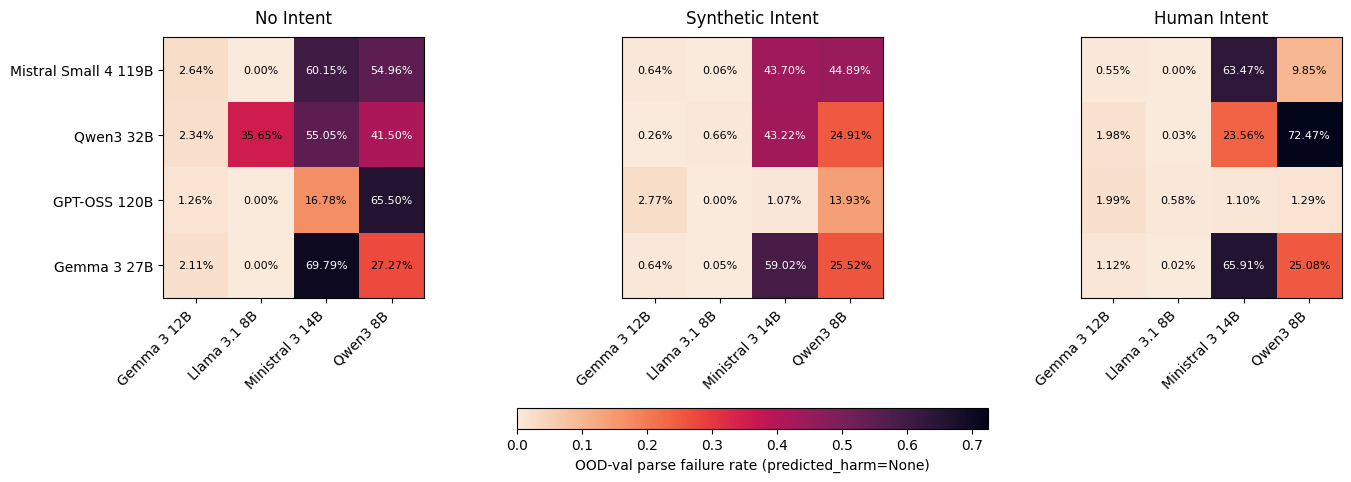

In [35]:
# 3-panel heatmap of parse-failure rate, matching the OOD-F1 figure layout.
heat_df = (
    parse_df.groupby(["teacher", "student", "condition"], as_index=False, observed=True)
    .agg(
        rows=("n_total", "sum"),
        parse_failures=("n_none", "sum"),
    )
    .assign(parse_fail_rate=lambda d: d["parse_failures"] / d["rows"])
)

fig, axes = plt.subplots(1, len(CONDITION_SLUG_ORDER), figsize=(16, 4.5), sharey=True)
if len(CONDITION_SLUG_ORDER) == 1:
    axes = [axes]
for ax in axes[1:]:
    ax.yaxis.set_visible(False)

heatmap_min = 0.0
heatmap_max = float(heat_df["parse_fail_rate"].max(skipna=True))
cmap = sns.color_palette("rocket_r", as_cmap=True)

for ax, condition_slug in zip(axes, CONDITION_SLUG_ORDER):
    condition_name = CONDITIONS[condition_slug]
    pivot = (
        heat_df[heat_df["condition"] == condition_name]
        .pivot(index="teacher", columns="student", values="parse_fail_rate")
        .reindex(index=TEACHER_ORDER, columns=STUDENT_ORDER)
    )
    image = ax.imshow(pivot.values, vmin=heatmap_min, vmax=heatmap_max, cmap=cmap)
    ax.set_title(condition_name, pad=10)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cell_value = pivot.iloc[i, j]
            if pd.isna(cell_value):
                ax.text(j, i, "—", ha="center", va="center", color="#888", fontsize=8)
                continue
            norm_val = (cell_value - heatmap_min) / (heatmap_max - heatmap_min + 1e-12)
            text_color = "white" if norm_val > 0.55 else "black"
            ax.text(j, i, f"{cell_value:.2%}", ha="center", va="center", color=text_color, fontsize=8)

fig.subplots_adjust(wspace=0, left=0.11, right=0.97, bottom=0.36, top=0.94)
_p0, _p2 = axes[0].get_position(), axes[-1].get_position()
_cbar_total_w = _p2.x1 - _p0.x0
_cbar_w = _cbar_total_w * 0.4
_cbar_left = _p0.x0 + (_cbar_total_w - _cbar_w) / 2
cbar_ax = fig.add_axes([_cbar_left, 0.07, _cbar_w, 0.045])
fig.colorbar(image, cax=cbar_ax, orientation="horizontal", label="OOD-val parse failure rate (predicted_harm=None)")
fig.savefig(FIGURES_DIR / "distillation_parse_failure_heatmap.pdf", bbox_inches="tight")
plt.show()